============================================================
# CELL 1: SETUP ENVIRONMENT
============================================================

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import os
import urllib.request

# Cek device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seed untuk reproduksibilitas
torch.manual_seed(42)
np.random.seed(42)

print("✅ Environment setup complete!")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
✅ Environment setup complete!
PyTorch version: 2.11.0+cpu


============================================================
# CELL 2: LOAD DATASET CIFAR-10
============================================================

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

LOAD CIFAR-10 DATASET

✅ CIFAR-10 Loaded!
   Training samples: 50000
   Testing samples: 10000

📷 Sample images from CIFAR-10 (Grayscale):


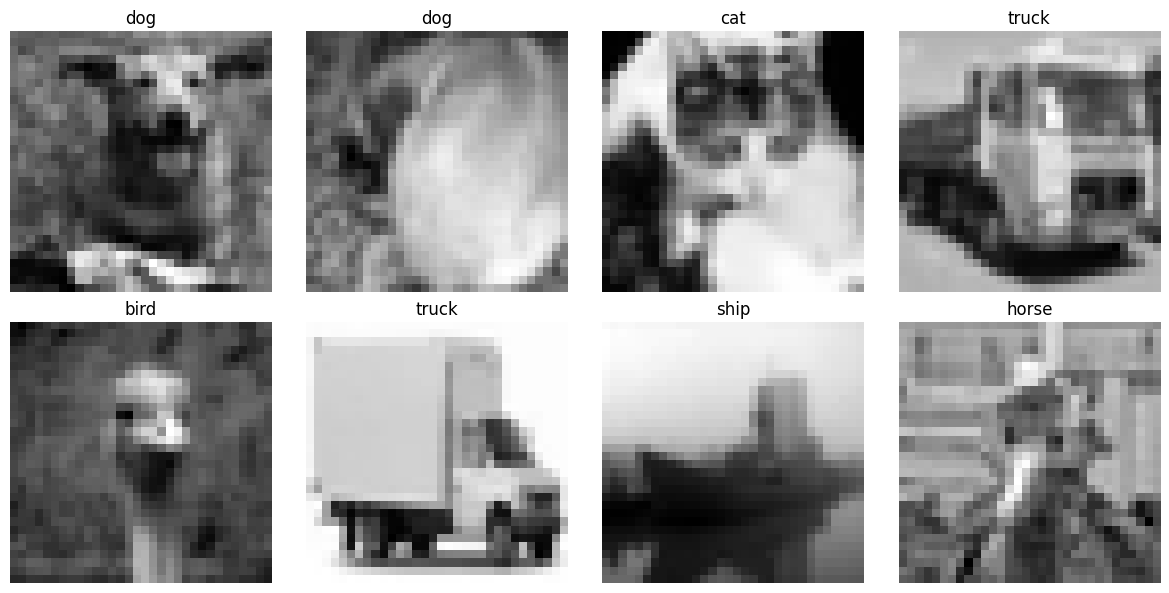

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
from google.colab import drive

drive.mount('/content/drive')
DATASET_PATH = '/content/drive/MyDrive/dataset/cifar-10-batches/'
TRAIN_BATCHES = ['data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5']
TEST_BATCH = 'test_batch'

class CIFAR10Dataset(Dataset):
    def __init__(self, root_dir, batch_files, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.data = []
        self.targets = []
        for f in batch_files:
            file_path = os.path.join(self.root_dir, f)
            with open(file_path, 'rb') as fo:
                entry = pickle.load(fo, encoding='latin1')
                self.data.append(entry['data'])
                self.targets.extend(entry.get('labels', entry.get('fine_labels')))
        self.data = np.vstack(self.data).reshape(-1, 3, 32, 32).transpose((0, 2, 3, 1))
        self.classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, target = self.data[idx], self.targets[idx]
        if self.transform:
            from PIL import Image
            img = Image.fromarray(img)
            img = self.transform(img)
        return img, target

def load_cifar10_dataset(batch_size=128, grayscale=False):
    t_list = []
    if grayscale:
        t_list.append(transforms.Grayscale(num_output_channels=1))
    t_list.extend([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    transform = transforms.Compose(t_list)

    train_dataset = CIFAR10Dataset(DATASET_PATH, TRAIN_BATCHES, transform=transform)
    test_dataset = CIFAR10Dataset(DATASET_PATH, [TEST_BATCH], transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, test_loader, train_dataset, test_dataset

# --- Eksekusi dan Visualisasi ---
print("\n" + "="*50)
print("LOAD CIFAR-10 DATASET")
print("="*50)

# Load data (Default grayscale untuk LeNet-5)
train_loader, test_loader, train_dataset, test_dataset = load_cifar10_dataset(batch_size=128, grayscale=True)

print(f"\n✅ CIFAR-10 Loaded!")
print(f"   Training samples: {len(train_dataset)}")
print(f"   Testing samples: {len(test_dataset)}")

def show_samples(loader, num_samples=8):
    images, labels = next(iter(loader))
    plt.figure(figsize=(12, 6))
    for i in range(min(num_samples, len(images))):
        plt.subplot(2, 4, i+1)
        img = images[i].numpy().squeeze() # squeeze untuk 1 channel
        img = (img * 0.5) + 0.5
        plt.imshow(img, cmap='gray')
        plt.title(f"{train_dataset.classes[labels[i].item()]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("\n📷 Sample images from CIFAR-10 (Grayscale):")
show_samples(train_loader)


============================================================
# CELL 3: CREATE LENET-5 MODEL (ATAU TRAINING DARI AWAL)
============================================================

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import os

# --- 1. Model & Path ---
model_path = '/content/drive/MyDrive/model/lenet5_cifar10.pth'

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 6 * 6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = x.flatten(1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# --- 2. Load Data ---
train_loader, test_loader, train_dataset, test_dataset = load_cifar10_dataset(batch_size=128, grayscale=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet5().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# --- 3. Load Checkpoint (Resume Logic) ---
start_epoch = 0
training_history = {'loss': [], 'accuracy': []}

if os.path.exists(model_path):
    print(f"\n✅ Menemukan model di {model_path}. Memuat progress...")
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    # Muat state optimizer agar learning rate/momentum konsisten
    if 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    if 'history' in checkpoint:
        training_history = checkpoint['history']
        start_epoch = len(training_history['accuracy'])
        print(f"✅ Progress ditemukan: Selesai {start_epoch} epoch. Melanjutkan ke epoch {start_epoch + 1}...")

# --- 4. Training Loop ---
num_epochs = 100

if start_epoch >= num_epochs:
    print(f"\n✅ Model sudah mencapai target {num_epochs} epoch. Selesai!")
else:
    for epoch in range(start_epoch, num_epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                pred = model(data).argmax(dim=1)
                correct += pred.eq(target).sum().item()

        accuracy = 100. * correct / len(test_dataset)
        training_history['loss'].append(running_loss/len(train_loader))
        training_history['accuracy'].append(accuracy)

        print(f"Epoch {epoch+1} Selesai - Loss: {training_history['loss'][-1]:.4f} - Acc: {accuracy:.2f}%")

        # Simpan progres termasuk optimizer state
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': training_history
        }, model_path)

print("\n✅ Selesai!")


✅ Menemukan model di /content/drive/MyDrive/model/lenet5_cifar10.pth. Memuat progress...
✅ Progress ditemukan: Selesai 30 epoch. Melanjutkan ke epoch 31...


Epoch 31/100: 100%|██████████| 391/391 [00:19<00:00, 19.85it/s]


Epoch 31 Selesai - Loss: 0.5934 - Acc: 62.90%


Epoch 32/100: 100%|██████████| 391/391 [00:18<00:00, 20.69it/s]


Epoch 32 Selesai - Loss: 0.5787 - Acc: 63.50%


...

Epoch 98 Selesai - Loss: 0.1246 - Acc: 58.95%


Epoch 99/100: 100%|██████████| 391/391 [00:18<00:00, 21.47it/s]


Epoch 99 Selesai - Loss: 0.1254 - Acc: 58.75%


Epoch 100/100: 100%|██████████| 391/391 [00:19<00:00, 20.23it/s]


Epoch 100 Selesai - Loss: 0.1070 - Acc: 59.04%

✅ Selesai!


============================================================
# CELL 4: IMPLEMENTASI FGQ TERNARY QUANTIZATION
============================================================

## Fine-Grained Quantization Ternary

In [ ]:
def ternary_quantize_group(weight_tensor, group_size=4):
    """
    Melakukan ternary quantization per group (FGQ)

    Args:
        weight_tensor: Tensor bobot
        group_size (N): Jumlah bobot per kelompok

    Returns:
        ternary_weights: Bobot ternary {-alpha, 0, +alpha}
        alphas: Faktor skala per kelompok
    """
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    n = flat_weights.numel()

    ternary_flat = torch.zeros_like(flat_weights)
    alphas = []

    for i in range(0, n, group_size):
        group = flat_weights[i:min(i+group_size, n)]
        group_size_actual = len(group)

        if group_size_actual == 0:
            continue

        abs_group = torch.abs(group)

        # Jika semua bobot 0
        if abs_group.max().item() == 0:
            alphas.append(0.0)
            continue

        # Cari threshold optimal (20 kandidat)
        thresholds = torch.linspace(
            abs_group.min().item(),
            abs_group.max().item(),
            steps=20
        )

        best_delta = 0
        best_score = -float('inf')

        for delta in thresholds:
            mask = abs_group > delta
            if mask.sum() == 0:
                continue
            sum_abs = abs_group[mask].sum()
            count = mask.sum().float()
            score = (sum_abs ** 2) / count
            if score > best_score:
                best_score = score
                best_delta = delta

        # Hitung alpha
        mask = abs_group > best_delta
        if mask.sum() == 0:
            alphas.append(0.0)
            continue

        alpha = abs_group[mask].sum() / mask.sum().float()
        alphas.append(alpha.item())

        # Buat ternary weights
        ternary_group = torch.zeros_like(group)
        ternary_group[group > best_delta] = alpha
        ternary_group[group < -best_delta] = -alpha

        ternary_flat[i:min(i+group_size, n)] = ternary_group

    return ternary_flat.reshape(original_shape), alphas

def apply_fgq_to_model(model, group_size=4, verbose=True):
    """
    Menerapkan FGQ ke semua layer konvolusi dan linear
    """
    print(f"\n🔧 Applying FGQ with N={group_size}...")
    alpha_means = []
    layer_names = []
    total_params = 0

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            original_weight = module.weight.data
            total_params += original_weight.numel()

            ternary_weight, alphas = ternary_quantize_group(
                original_weight,
                group_size=group_size
            )
            module.weight.data = ternary_weight

            alpha_mean = np.mean(alphas) if alphas else 0
            alpha_means.append(alpha_mean)
            layer_names.append(name)

            if verbose:
                num_groups = original_weight.numel() // group_size if group_size > 0 else 0
                print(f"  ✓ {name}: {original_weight.shape}, "
                      f"groups={num_groups}, α_mean={alpha_mean:.4f}")

    print(f"   Total parameters quantized: {total_params:,}")
    return model, alpha_means, layer_names

print("\n" + "="*50)
print("CELL 5: FGQ IMPLEMENTATION READY")
print("="*50)

print("✅ FGQ functions defined!")
print("   - ternary_quantize_group(): quantize per group")
print("   - apply_fgq_to_model(): apply to entire model")


CELL 5: FGQ IMPLEMENTATION READY
✅ FGQ functions defined!
   - ternary_quantize_group(): quantize per group
   - apply_fgq_to_model(): apply to entire model


## Standard Quantization Ternary

In [ ]:
def standard_ternary_quantize(weight_tensor):
    """
    Melakukan standard ternary quantization pada seluruh tensor bobot
    (Global quantization, bukan per group/fine-grained)
    """
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    abs_weights = torch.abs(flat_weights)

    # Jika semua bobot 0
    if abs_weights.max().item() == 0:
        return torch.zeros_like(weight_tensor), 0.0

    # Mencari threshold optimal secara global (berdasarkan rata-rata absolut)
    # Metode umum: delta = 0.7 * E[|W|]
    delta = 0.7 * torch.mean(abs_weights)

    # Hitung mask untuk nilai yang lebih besar dari threshold
    mask = abs_weights > delta

    if mask.sum() == 0:
        return torch.zeros_like(weight_tensor), 0.0

    # Hitung alpha (skala) global
    alpha = abs_weights[mask].sum() / mask.sum().float()

    # Buat ternary weights
    ternary_flat = torch.zeros_like(flat_weights)
    ternary_flat[flat_weights > delta] = alpha
    ternary_flat[flat_weights < -delta] = -alpha

    return ternary_flat.reshape(original_shape), alpha.item()

def apply_standard_ternary_to_model(model, verbose=True):
    """
    Menerapkan Standard Ternary Quantization ke semua layer konvolusi dan linear
    """
    print(f"\n🔧 Applying Standard Ternary Quantization (Global)...")
    layer_alphas = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            original_weight = module.weight.data

            ternary_weight, alpha = standard_ternary_quantize(original_weight)
            module.weight.data = ternary_weight

            layer_alphas.append(alpha)

            if verbose:
                print(f"  ✓ {name}: {original_weight.shape}, α={alpha:.4f}")

    return model, layer_alphas

print("\n" + "="*50)
print("CELL 5.1: STANDARD TERNARY QUANTIZATION READY")
print("="*50)
print("✅ Standard Ternary functions defined!")


CELL 5.1: STANDARD TERNARY QUANTIZATION READY
✅ Standard Ternary functions defined!


============================================================
# CELL 5: SKENARIO A - DENGAN STANDARD QUANTIZATION
============================================================


CELL 9: SKENARIO C - STANDARD TERNARY QUANTIZATION (LeNet-5)
📊 Mengambil Baseline Accuracy dari model LeNet-5 di memori...

📊 Baseline accuracy (FP32): 62.28%

🔧 Applying Standard Ternary Quantization (Global)...
  ✓ conv1: torch.Size([6, 1, 5, 5]), α=0.2874
  ✓ conv2: torch.Size([16, 6, 5, 5]), α=0.2442
  ✓ fc1: torch.Size([120, 576]), α=0.1417
  ✓ fc2: torch.Size([84, 120]), α=0.1881
  ✓ fc3: torch.Size([10, 84]), α=0.3250

📊 Evaluating Standard Ternary model...

✅ Standard Ternary Top-1 Accuracy: 22.35%
   Drop from baseline: 39.93%


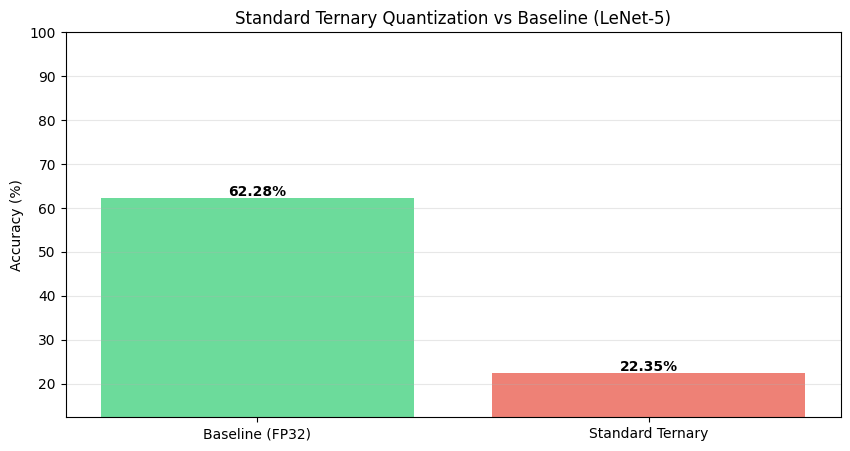


----------------------------------------
📝 Technical Summary (LeNet-5):
   - Quantization Level: 2-bit (Ternary)
   - Granularity: Global (Per Layer)
   - Final Accuracy: 22.35%
   - Accuracy Drop: 39.93%
----------------------------------------

✅ CELL 9 COMPLETED!


In [ ]:
print("\n" + "="*50)
print("CELL 9: SKENARIO C - STANDARD TERNARY QUANTIZATION (LeNet-5)")
print("="*50)

def evaluate_accuracy(model, data_loader, verbose=False):
    """
    Evaluasi akurasi model
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total
    return accuracy

# --- Persiapan Baseline ---
# Mengambil model yang sudah terlatih di memori (LeNet-5 dari Cell 3)
print("📊 Mengambil Baseline Accuracy dari model LeNet-5 di memori...")
baseline_acc = evaluate_accuracy(model, test_loader)

# Simpan state awal untuk reset selama testing
import copy
baseline_state = copy.deepcopy(model.state_dict())

print(f"\n📊 Baseline accuracy (FP32): {baseline_acc:.2f}%")

# 1. Pastikan baseline model tersedia
try:
    # Inisialisasi model LeNet-5 dan muat state baseline
    model_st = LeNet5().to(device)
    model_st.load_state_dict(baseline_state)
    model_st.eval()

    # 2. Terapkan Standard Ternary Quantization (Global)
    model_st, layer_alphas = apply_standard_ternary_to_model(model_st, verbose=True)

    # 3. Evaluasi Akurasi
    print("\n📊 Evaluating Standard Ternary model...")
    acc_st = evaluate_accuracy(model_st, test_loader, verbose=False)

    drop_st = baseline_acc - acc_st

    print(f"\n✅ Standard Ternary Top-1 Accuracy: {acc_st:.2f}%")
    print(f"   Drop from baseline: {drop_st:.2f}%")

    # 4. Visualisasi Perbandingan (Standard vs Baseline)
    plt.figure(figsize=(10, 5))
    labels = ['Baseline (FP32)', 'Standard Ternary']
    accuracies = [baseline_acc, acc_st]
    colors = ['#2ecc71', '#e74c3c']

    plt.bar(labels, accuracies, color=colors, alpha=0.7)
    plt.ylabel('Accuracy (%)')
    plt.title('Standard Ternary Quantization vs Baseline (LeNet-5)')
    plt.ylim(max(0, min(accuracies) - 10), 100)
    plt.grid(True, axis='y', alpha=0.3)

    for i, acc in enumerate(accuracies):
        plt.text(i, acc + 0.5, f"{acc:.2f}%", ha='center', fontweight='bold')

    plt.show()

    # 5. Ringkasan Teknis
    print("\n" + "-"*40)
    print(f"📝 Technical Summary (LeNet-5):")
    print(f"   - Quantization Level: 2-bit (Ternary)")
    print(f"   - Granularity: Global (Per Layer)")
    print(f"   - Final Accuracy: {acc_st:.2f}%")
    print(f"   - Accuracy Drop: {drop_st:.2f}%")
    print("-"*40)

except NameError as e:
    print(f"❌ ERROR: {e}")
    print("💡 Silakan jalankan cell pendefinisian model (Cell 3) terlebih dahulu.")

print("\n✅ CELL 9 COMPLETED!")

============================================================
# CELL 6: SKENARIO B - DENGAN FINE-GRAINED QUANTIZATION
============================================================


Testing N = 2

🔧 Applying FGQ with N=2...
  ✓ conv1: torch.Size([6, 1, 5, 5]), groups=75, α_mean=0.2706
  ✓ conv2: torch.Size([16, 6, 5, 5]), groups=1200, α_mean=0.1971
  ✓ fc1: torch.Size([120, 576]), groups=34560, α_mean=0.1108
  ✓ fc2: torch.Size([84, 120]), groups=5040, α_mean=0.1648
  ✓ fc3: torch.Size([10, 84]), groups=420, α_mean=0.3088
   Total parameters quantized: 82,590

📊 Evaluating FGQ model (without fine-tuning)...

✅ FGQ N=2 Top-1 Accuracy: 20.38%
   Drop from baseline: 41.90%

Testing N = 4

🔧 Applying FGQ with N=4...
  ✓ conv1: torch.Size([6, 1, 5, 5]), groups=37, α_mean=0.2871
  ✓ conv2: torch.Size([16, 6, 5, 5]), groups=600, α_mean=0.2063
  ✓ fc1: torch.Size([120, 576]), groups=17280, α_mean=0.1191
  ✓ fc2: torch.Size([84, 120]), groups=2520, α_mean=0.1987
  ✓ fc3: torch.Size([10, 84]), groups=210, α_mean=0.3289
   Total parameters quantized: 82,590

📊 Evaluating FGQ model (without fine-tuning)...

✅ FGQ N=4 Top-1 Accuracy: 46.23%
   Drop from baseline: 16.05%

Test

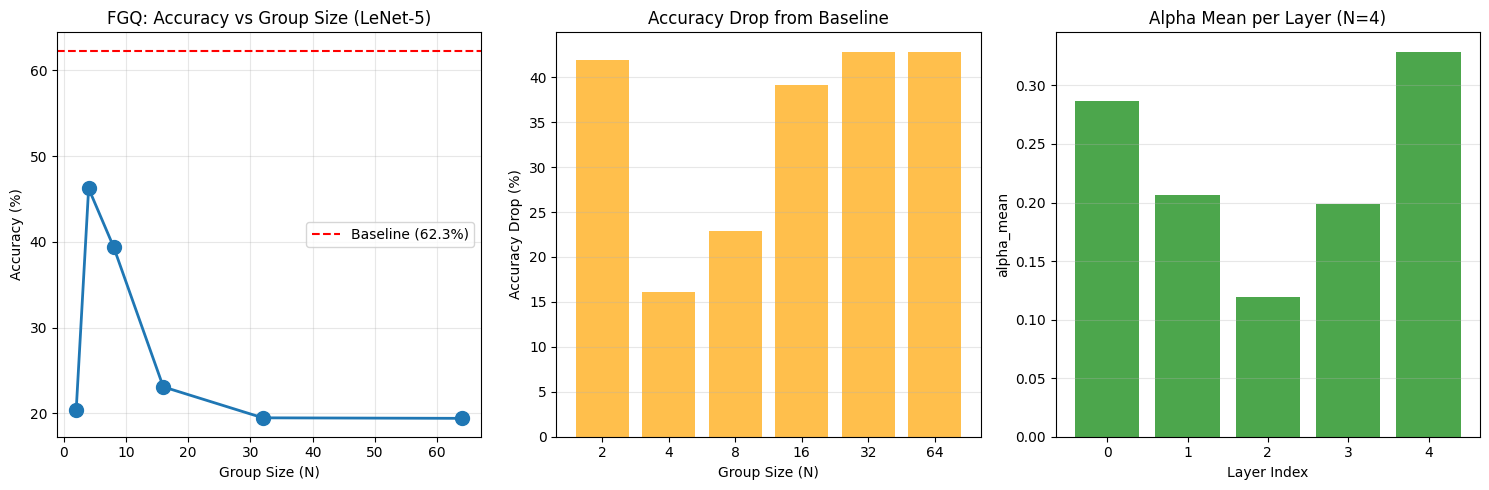


✅ CELL 6 COMPLETED!


In [ ]:
# Test dengan berbagai group size
group_sizes = [2, 4, 8, 16, 32, 64]
results = {'N': [], 'accuracy': [], 'drop': [], 'alpha_means': []}

for N in group_sizes:
    print(f"\n{'='*40}")
    print(f"Testing N = {N}")
    print(f"{'='*40}")

    # FIXED: Gunakan LeNet5() karena arsitektur sekarang adalah LeNet-5
    test_model = LeNet5().to(device)
    test_model.load_state_dict(baseline_state)
    test_model.eval()

    # Apply FGQ
    test_model, alpha_means, layer_names = apply_fgq_to_model(test_model, group_size=N, verbose=True)

    # Evaluasi
    print("\n📊 Evaluating FGQ model (without fine-tuning)...")
    acc = evaluate_accuracy(test_model, test_loader, verbose=True)

    drop = baseline_acc - acc
    print(f"\n✅ FGQ N={N} Top-1 Accuracy: {acc:.2f}%")
    print(f"   Drop from baseline: {drop:.2f}%")

    results['N'].append(N)
    results['accuracy'].append(acc)
    results['drop'].append(drop)
    results['alpha_means'].append(alpha_means)

# Visualisasi hasil
plt.figure(figsize=(15, 5))

# Plot 1: Accuracy vs Group Size
plt.subplot(1, 3, 1)
plt.plot(results['N'], results['accuracy'], marker='o', linewidth=2, markersize=10)
plt.axhline(y=baseline_acc, color='r', linestyle='--',
            label=f'Baseline ({baseline_acc:.1f}%)')
plt.xlabel('Group Size (N)')
plt.ylabel('Accuracy (%)')
plt.title('FGQ: Accuracy vs Group Size (LeNet-5)')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Drop in Accuracy
plt.subplot(1, 3, 2)
plt.bar([str(n) for n in results['N']], results['drop'], color='orange', alpha=0.7)
plt.xlabel('Group Size (N)')
plt.ylabel('Accuracy Drop (%)')
plt.title('Accuracy Drop from Baseline')
plt.grid(True, alpha=0.3, axis='y')

# Plot 3: Alpha Mean per Layer (N=4, index 1)
plt.subplot(1, 3, 3)
if len(results['alpha_means']) > 1:
    alpha_means_4 = results['alpha_means'][1]  # Index 1 untuk N=4
    plt.bar(range(len(alpha_means_4)), alpha_means_4, alpha=0.7, color='green')
    plt.xlabel('Layer Index')
    plt.ylabel('alpha_mean')
    plt.title(f'Alpha Mean per Layer (N=4)')
    plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✅ CELL 6 COMPLETED!")

============================================================
# CELL 7: PERBANDINGAN SKENARIO A vs B
============================================================


CELL 7: PERBANDINGAN AKURASI TERBAIK


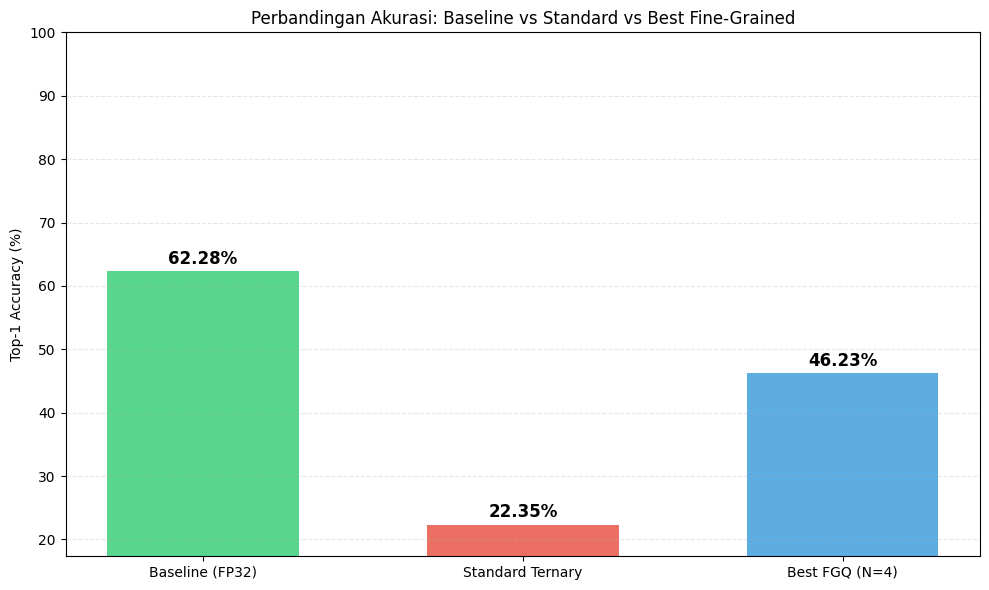


RINGKASAN PERBANDINGAN
1. Akurasi Baseline (FP32)  : 62.28%
2. Akurasi Standard Ternary : 22.35% (Drop: 39.93%)
3. Akurasi Terbaik FGQ (N=4): 46.23% (Drop: 16.05%)

💡 Kesimpulan Utama:
✔ FGQ dengan N=4 memberikan hasil yang paling mendekati model asli (FP32).
✔ Bar chart di atas menunjukkan bahwa pendekatan Fine-Grained jauh lebih efektif
   dalam mempertahankan akurasi dibandingkan pendekatan Standard (Global) pada level ternary.

✅ ANALISIS PERBANDINGAN SELESAI!


In [ ]:
print("\n" + "="*50)
print("CELL 7: PERBANDINGAN AKURASI TERBAIK")
print("="*50)

# Ambil akurasi terbaik dari FGQ
best_fgq_acc = max(results['accuracy'])
best_n = results['N'][results['accuracy'].index(best_fgq_acc)]

# Data untuk bar chart
labels = ['Baseline (FP32)', 'Standard Ternary', f'Best FGQ (N={best_n})']
values = [baseline_acc, acc_st, best_fgq_acc]
colors = ['#2ecc71', '#e74c3c', '#3498db']

plt.figure(figsize=(10, 6))

# Membuat bar chart
bars = plt.bar(labels, values, color=colors, alpha=0.8, width=0.6)

# Dekorasi Plot
plt.ylabel('Top-1 Accuracy (%)')
plt.title('Perbandingan Akurasi: Baseline vs Standard vs Best Fine-Grained')
plt.ylim(max(0, min(values) - 5), 100)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')

# Tambahkan label nilai di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# --- Insight & Kesimpulan ---
print("\n" + "="*50)
print("RINGKASAN PERBANDINGAN")
print("="*50)

print(f"1. Akurasi Baseline (FP32)  : {baseline_acc:.2f}%")
print(f"2. Akurasi Standard Ternary : {acc_st:.2f}% (Drop: {baseline_acc - acc_st:.2f}%)")
print(f"3. Akurasi Terbaik FGQ (N={best_n}): {best_fgq_acc:.2f}% (Drop: {baseline_acc - best_fgq_acc:.2f}%)")

print("\n💡 Kesimpulan Utama:")
print(f"✔ FGQ dengan N={best_n} memberikan hasil yang paling mendekati model asli (FP32).")
print("✔ Bar chart di atas menunjukkan bahwa pendekatan Fine-Grained jauh lebih efektif")
print("   dalam mempertahankan akurasi dibandingkan pendekatan Standard (Global) pada level ternary.")

print("\n✅ ANALISIS PERBANDINGAN SELESAI!")